In [16]:
import numpy as np 
import matplotlib.pyplot as plt

In [17]:
#le equazioni da risolvere 
def DerP(P,R,V,xi):
    return P/2 * (3*xi*(gamma+1)-V*(6+gamma-(8*gamma*V)/(xi*(gamma+1))))/((xi*(gamma+1)/2-V)*(2*V/(gamma+1)-xi)
                                                                      +gamma*P/R*(gamma-1)/(gamma+1))

def DerR(P,R,V,xi):
    return R/gamma*(DerP(P,R,V,xi)/P+3/(xi-2*V/(gamma+1)))

def DerV(P,R,V,xi): 
    return DerR(P,R,V,xi)/R*((gamma+1)/2*xi-V)-2*V/xi

def eq_differenziale(y,xi): 
    return np.array([DerP(y[0],y[1],y[2],xi),DerR(y[0],y[1],y[2],xi),DerV(y[0],y[1],y[2],xi)])

#condizione iniziale: 
y1 = [1,1,1]

In [18]:
def rk4(f,v0,t0,tf,n,V):  
    t=np.linspace(t0,tf,n)
    h=t[1]-t[0]
    v=v0
    for j in range(n):  
        V.append(v)
        k1=f(v,t[j])*h
        k2=f(v+0.5*k1,t[j]+0.5*h)*h
        k3=f(v+0.5*k2,t[j]+0.5*h)*h
        k4=f(v+k3,t[j]+h)*h
        v=v+(k1+2*k2+2*k3+k4)/6
    return V, t

In [19]:
gamma = 5/3
V1, t1= rk4(eq_differenziale,y1,1,0,1000000,[])
V1 = np.array(V1)

C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:3: RuntimeWarning: divide by zero encountered in double_scalars
  return P/2 * (3*xi*(gamma+1)-V*(6+gamma-(8*gamma*V)/(xi*(gamma+1))))/((xi*(gamma+1)/2-V)*(2*V/(gamma+1)-xi)
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:10: RuntimeWarning: divide by zero encountered in double_scalars
  return DerR(P,R,V,xi)/R*((gamma+1)/2*xi-V)-2*V/xi
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:10: RuntimeWarning: invalid value encountered in double_scalars
  return DerR(P,R,V,xi)/R*((gamma+1)/2*xi-V)-2*V/xi
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:4: RuntimeWarning: invalid value encountered in double_scalars
  +gamma*P/R*(gamma-1)/(gamma+1))


In [20]:
gamma = 7/5
V2, t2= rk4(eq_differenziale,y1,1,0,1000000,[])
V2 = np.array(V2)

C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:3: RuntimeWarning: divide by zero encountered in double_scalars
  return P/2 * (3*xi*(gamma+1)-V*(6+gamma-(8*gamma*V)/(xi*(gamma+1))))/((xi*(gamma+1)/2-V)*(2*V/(gamma+1)-xi)
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:10: RuntimeWarning: divide by zero encountered in double_scalars
  return DerR(P,R,V,xi)/R*((gamma+1)/2*xi-V)-2*V/xi
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:4: RuntimeWarning: invalid value encountered in double_scalars
  +gamma*P/R*(gamma-1)/(gamma+1))


In [21]:
gamma = 9/7
V3, t3= rk4(eq_differenziale,y1,1,0,1000000,[])
V3 = np.array(V3)

C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:3: RuntimeWarning: divide by zero encountered in double_scalars
  return P/2 * (3*xi*(gamma+1)-V*(6+gamma-(8*gamma*V)/(xi*(gamma+1))))/((xi*(gamma+1)/2-V)*(2*V/(gamma+1)-xi)
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:10: RuntimeWarning: divide by zero encountered in double_scalars
  return DerR(P,R,V,xi)/R*((gamma+1)/2*xi-V)-2*V/xi
C:\Users\frede\AppData\Local\Temp/ipykernel_8268/2041603829.py:4: RuntimeWarning: invalid value encountered in double_scalars
  +gamma*P/R*(gamma-1)/(gamma+1))


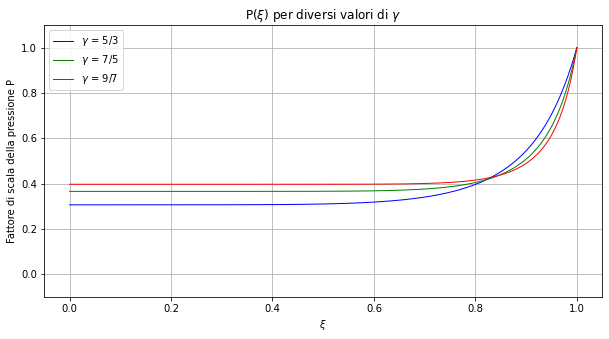

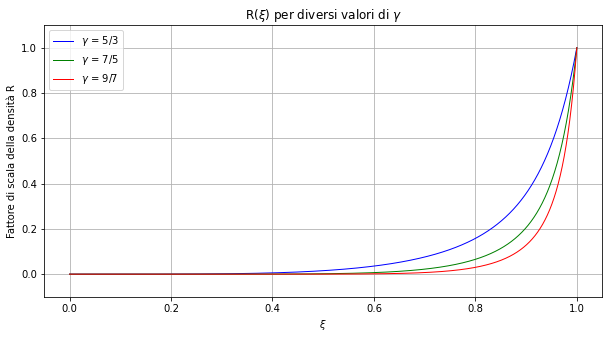

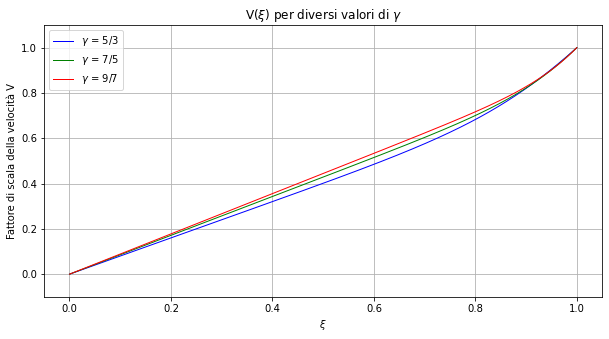

In [22]:
plt.figure(num = 1, figsize = (10,5))
plt.title(label = r"P($\xi$) per diversi valori di $\gamma$")
plt.plot(t1,V1[:,0],label = "$\gamma$ = 5/3", color = "blue", lw = 1)
plt.plot(t2,V2[:,0],label = "$\gamma$ = 7/5", color = "green", lw = 1)
plt.plot(np.delete(t3,-1),np.delete(V3[:,0],-1),label = "$\gamma$ = 9/7", color = "red", lw = 1)
plt.xlabel(r"$\xi$")
plt.ylabel("Fattore di scala della pressione P")
plt.grid()
plt.legend()
plt.ylim(-0.1,1.1)
plt.savefig("PlotsFluido/PlotP.pdf")

plt.figure(num = 2,figsize = (10,5))
plt.title(label = r"R($\xi$) per diversi valori di $\gamma$")
plt.plot(t1,V1[:,1],label = "$\gamma$ = 5/3", color = "blue", lw = 1)
plt.plot(t2,V2[:,1],label = "$\gamma$ = 7/5", color = "green", lw = 1)
plt.plot(t3,V3[:,1],label = "$\gamma$ = 9/7", color = "red", lw = 1)
plt.xlabel(r"$\xi$")
plt.ylabel("Fattore di scala della densità R")
plt.legend()
plt.grid()
plt.ylim(-0.1,1.1)
plt.savefig("PlotsFluido/PlotR.pdf")

plt.figure(num = 3,figsize = (10,5))
plt.title(label = r"V($\xi$) per diversi valori di $\gamma$")
plt.plot(t1[V1[:,2]>0],V1[:,2][V1[:,2]>0],label = "$\gamma$ = 5/3", color = "blue", lw = 1)
plt.plot(t2[V2[:,2]>0],V2[:,2][V2[:,2]>0],label = "$\gamma$ = 7/5", color = "green", lw = 1)
plt.plot(t3[V3[:,2]>0],V3[:,2][V3[:,2]>0],label = "$\gamma$ = 9/7", color = "red", lw = 1)
plt.xlabel(r"$\xi$")
plt.ylabel("Fattore di scala della velocità V")
plt.legend()
plt.grid()
plt.ylim(-0.1,1.1)
plt.savefig("PlotsFluido/PlotV.pdf")